# Rail Operations Forecaster
## Notebook 09 — Multi-Step Forecasting and Short-Horizon Planning

**Business Objective:**  
This notebook extends the project from next-day tactical forecasting into short-horizon planning support. Using the tuned Phase 1 LightGBM framework, we evaluate how forecast performance changes as the planning horizon grows from day+1 out to day+7. The goal is to understand how far forward current operational conditions remain informative — and where the forecasting signal begins to degrade.

**Phase context:**  
- Phase 1 established the LightGBM benchmark at day+1 (RMSE 3.749h, MAE 2.879h)
- Phase 2 benchmarked temporal LSTM models — the Phase 2 gate was not cleared
- Phase 3 built a decision-support layer with operational risk thresholds
- **Phase 4 (this notebook):** Direct multi-step forecasting across day+1, day+3, day+5, day+7 horizons

---
## 1. Why Multi-Step Forecasting Matters

Rail operations planning happens across multiple timescales:

| Horizon | Use case | Who acts |
|---|---|---|
| Day +1 | Tactical response — crew deployment, locomotive repositioning | Terminal supervisor |
| Day +3 | Early warning — plan inbound surge response, pre-position equipment | District planner |
| Day +5 | Short-horizon planning — coordinate intermodal schedules, maintenance windows | Regional manager |
| Day +7 | Weekly planning — network-wide capacity decisions | Operations leadership |

**The core question:** Does today's operational snapshot — yard occupancy, crew starts, locomotive availability — still carry useful signal 3, 5, or 7 days forward? And how does forecast accuracy change as the horizon extends?

In real-world operational forecasting, accuracy typically degrades with horizon. The further out we predict, the less informative today's conditions are, and the more uncertainty compounds. Understanding where that degradation starts is as important as knowing how well the model performs at day+1.

**Design choice — direct multi-step forecasting:**  
We train a separate model for each horizon rather than recursively rolling day+1 predictions forward. This avoids compounding prediction errors and produces cleaner, more interpretable comparisons. Each model sees the same current-day features and answers one specific question: *given today's conditions, what will dwell look like on day+h?*

---
## 2. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
DATA_PATH = Path.cwd().resolve().parent / "data" / "synthetic" / "phase1_terminal_dwell.csv"
SPLIT_DATE = pd.Timestamp("2024-07-01")

FEATURE_COLS = [
    "terminal_id",
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

HORIZONS = [1, 3, 5, 7]
DWELL_BREACH_THRESHOLD = 24.0  # hours — from Phase 3 decision-support layer
TUNED_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_child_samples": 20,
}

print(f"Data path: {DATA_PATH}")
print(f"Train/test split: {SPLIT_DATE.date()}")
print(f"Forecast horizons: {HORIZONS}")

Data path: /home/jorge/projects/rail-ops-forecaster/data/synthetic/phase1_terminal_dwell.csv
Train/test split: 2024-07-01
Forecast horizons: [1, 3, 5, 7]


---
## 3. Load and Prepare the Dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Sort by terminal then date — required for correct within-terminal lag shifts
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Terminals: {sorted(df['terminal_id'].unique())}")
print(f"\ntarget_dwell_hours — min {df['target_dwell_hours'].min():.1f}h, "
      f"mean {df['target_dwell_hours'].mean():.1f}h, "
      f"max {df['target_dwell_hours'].max():.1f}h")

Dataset shape: (8760, 13)
Date range: 2022-01-01 → 2024-12-30
Terminals: ['T01', 'T02', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08']

target_dwell_hours — min 6.0h, mean 19.1h, max 39.9h


---
## 4. Construct Direct Future Targets

In this dataset, `target_dwell_hours` for a row dated **day D** already represents the dwell outcome on **day D+1** — this is the standard one-step-ahead setup from Phase 1.

For multi-step forecasting we need to map today's features forward to dwell outcomes at longer horizons:

| Horizon | Target represents | Construction |
|---|---|---|
| t+1 | Dwell on D+1 | Use `target_dwell_hours` directly |
| t+3 | Dwell on D+3 | Shift `target_dwell_hours` by −2 within terminal |
| t+5 | Dwell on D+5 | Shift `target_dwell_hours` by −4 within terminal |
| t+7 | Dwell on D+7 | Shift `target_dwell_hours` by −6 within terminal |

Shifts are applied per terminal so we never borrow dwell values from a different yard.

In [3]:
def build_future_targets(df: pd.DataFrame, horizons: list[int]) -> pd.DataFrame:
    """Add direct future target columns by shifting within each terminal group."""
    df = df.copy()
    for h in horizons:
        # target_dwell_hours is already day+1 relative to the feature date.
        # Shifting by -(h-1) gives us the day+h outcome from those same features.
        shift_steps = h - 1
        col = f"target_dwell_t_plus_{h}"
        df[col] = (
            df.groupby("terminal_id")["target_dwell_hours"]
            .shift(-shift_steps)
        )
    return df


df = build_future_targets(df, HORIZONS)

target_cols = [f"target_dwell_t_plus_{h}" for h in HORIZONS]
print("Missing values per target (rows lost to end-of-terminal boundary):")
print(df[target_cols].isna().sum())

Missing values per target (rows lost to end-of-terminal boundary):
target_dwell_t_plus_1     0
target_dwell_t_plus_3    16
target_dwell_t_plus_5    32
target_dwell_t_plus_7    48
dtype: int64


---
## 5. Preview: Feature Date → Future Targets

To verify the target construction is correct, the table below shows a single terminal across several consecutive dates. Each row's features align with future dwell outcomes in the expected columns.

In [4]:
preview_cols = (
    ["date", "terminal_id", "yard_occupancy_pct", "crew_starts_available"]
    + target_cols
)

preview = (
    df[df["terminal_id"] == "T01"]
    .iloc[0:12][preview_cols]
    .reset_index(drop=True)
)

preview["date"] = preview["date"].dt.strftime("%Y-%m-%d")
print("Preview — T01 features mapped to future dwell targets:")
preview

Preview — T01 features mapped to future dwell targets:


,date,terminal_id,yard_occupancy_pct,crew_starts_available,target_dwell_t_plus_1,target_dwell_t_plus_3,target_dwell_t_plus_5,target_dwell_t_plus_7
0,2022-01-01,T01,59.100,13,19.700,20.000,20.700,22.100
1,2022-01-02,T01,51.200,11,19.500,20.400,20.200,17.300
2,2022-01-03,T01,49.800,18,20.000,20.700,22.100,14.500
3,2022-01-04,T01,38.900,14,20.400,20.200,17.300,16.000
4,2022-01-05,T01,40.100,17,20.700,22.100,14.500,23.800
5,2022-01-06,T01,46.400,19,20.200,17.300,16.000,18.800
6,2022-01-07,T01,29.400,18,22.100,14.500,23.800,16.800
7,2022-01-08,T01,44.200,14,17.300,16.000,18.800,16.500
8,2022-01-09,T01,27.800,14,14.500,23.800,16.800,19.600
9,2022-01-10,T01,24.600,25,16.000,18.800,16.500,18.300


Reading the table row-by-row: a row's `target_dwell_t_plus_1` is the next day's dwell, `target_dwell_t_plus_3` is the dwell three days out, and so on. The last rows in each terminal show NaN because there are no future rows to shift from — these are correctly excluded from training and evaluation.

---
## 6. Train Direct LightGBM Models — One Per Horizon

For each horizon we:
1. Drop rows with a missing future target
2. Split train / test based on the **target date** (feature date + horizon), not the feature date — this avoids data leakage at the holdout boundary
3. Fit the tuned LightGBM model with `terminal_id` as a native categorical
4. Compute RMSE and MAE on the held-out test set

> **Note on the Day+1 comparison:** The day+1 model here will be very close to the Phase 1 tuned benchmark (RMSE 3.749h, MAE 2.879h) but may not match it exactly, because this notebook applies a target-date-based split for consistency across all horizons rather than the feature-date split used in Phase 1. The difference is expected and does not invalidate the cross-horizon comparison.

In [5]:
def train_and_evaluate(df: pd.DataFrame, horizon: int) -> dict:
    target_col = f"target_dwell_t_plus_{horizon}"

    # Drop rows where the future target is unavailable
    df_h = df[df[target_col].notna()].copy()

    # Split based on the date being predicted, not the feature date
    target_date = df_h["date"] + pd.Timedelta(days=horizon)
    train_mask = target_date < SPLIT_DATE
    test_mask  = target_date >= SPLIT_DATE

    X_train = df_h.loc[train_mask, FEATURE_COLS].copy()
    X_test  = df_h.loc[test_mask,  FEATURE_COLS].copy()
    y_train = df_h.loc[train_mask, target_col]
    y_test  = df_h.loc[test_mask,  target_col]

    X_train["terminal_id"] = X_train["terminal_id"].astype("category")
    X_test["terminal_id"]  = X_test["terminal_id"].astype("category")

    model = LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        verbose=-1,
        **TUNED_PARAMS,
    )
    model.fit(X_train, y_train, categorical_feature=["terminal_id"])

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    return {
        "horizon": horizon,
        "horizon_label": f"Day +{horizon}",
        "train_rows": int(train_mask.sum()),
        "test_rows": int(test_mask.sum()),
        "rmse": rmse,
        "mae": mae,
        "y_test": y_test.values,
        "y_pred": y_pred,
        "model": model,
    }


results = {}
for h in HORIZONS:
    res = train_and_evaluate(df, h)
    results[h] = res
    print(
        f"Day +{h:1d}  |  train={res['train_rows']:,}  test={res['test_rows']:,}  "
        f"RMSE={res['rmse']:.3f}h  MAE={res['mae']:.3f}h"
    )

print("\nAll horizons trained.")

Day +1  |  train=7,288  test=1,472  RMSE=3.742h  MAE=2.876h
Day +3  |  train=7,272  test=1,472  RMSE=3.747h  MAE=2.885h
Day +5  |  train=7,256  test=1,472  RMSE=3.734h  MAE=2.868h
Day +7  |  train=7,240  test=1,472  RMSE=3.729h  MAE=2.868h

All horizons trained.


---
## 7. Forecast Performance Summary

### 7.1 Results table

In [6]:
# Reference: Phase 1 tuned model at day+1
PHASE1_RMSE = 3.749
PHASE1_MAE  = 2.879

rows = []
for h in HORIZONS:
    r = results[h]
    rows.append({
        "Horizon": r["horizon_label"],
        "Test rows": r["test_rows"],
        "RMSE (hours)": r["rmse"],
        "MAE (hours)": r["mae"],
        "RMSE vs Day+1 (%)": (r["rmse"] / results[1]["rmse"] - 1) * 100,
        "MAE vs Day+1 (%)": (r["mae"]  / results[1]["mae"]  - 1) * 100,
    })

results_df = pd.DataFrame(rows)
results_df["RMSE vs Day+1 (%)"] = results_df["RMSE vs Day+1 (%)"].map(
    lambda x: f"+{x:.1f}%" if x >= 0 else f"{x:.1f}%"
)
results_df["MAE vs Day+1 (%)"] = results_df["MAE vs Day+1 (%)"].map(
    lambda x: f"+{x:.1f}%" if x >= 0 else f"{x:.1f}%"
)

print("Multi-step forecast performance summary")
print(f"(Phase 1 reference — Day+1: RMSE {PHASE1_RMSE}h, MAE {PHASE1_MAE}h)")
print()
results_df.set_index("Horizon")

Multi-step forecast performance summary
(Phase 1 reference — Day+1: RMSE 3.749h, MAE 2.879h)



,Test rows,RMSE (hours),MAE (hours),RMSE vs Day+1 (%),MAE vs Day+1 (%)
Horizon,,,,,
Day +1,1472,3.742,2.876,+0.0%,+0.0%
Day +3,1472,3.747,2.885,+0.1%,+0.3%
Day +5,1472,3.734,2.868,-0.2%,-0.3%
Day +7,1472,3.729,2.868,-0.3%,-0.3%


### 7.2 RMSE by horizon

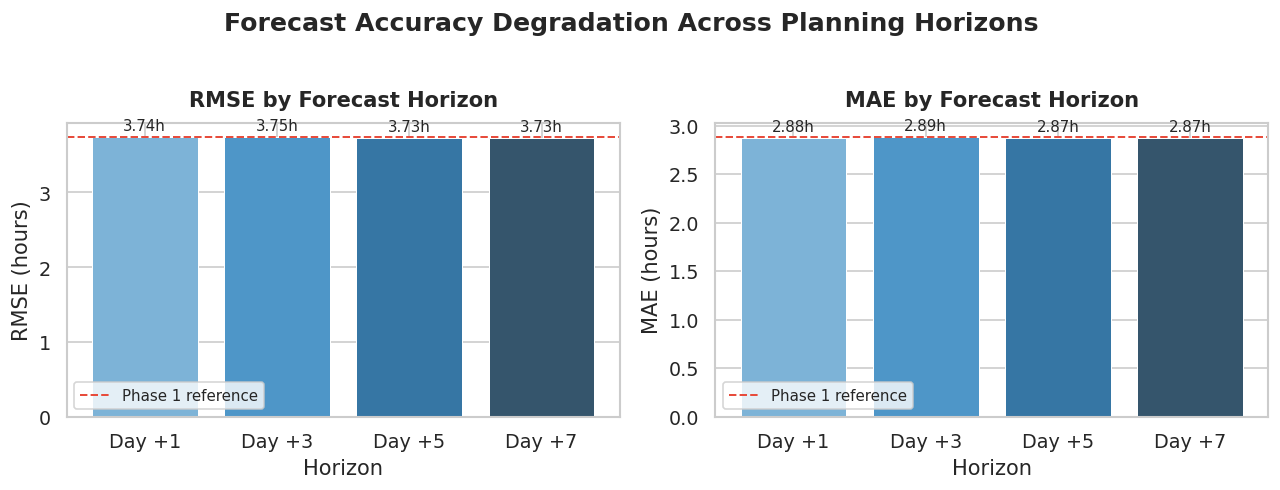

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

horizon_labels = [f"Day +{h}" for h in HORIZONS]
rmse_vals = [results[h]["rmse"] for h in HORIZONS]
mae_vals  = [results[h]["mae"]  for h in HORIZONS]

palette = sns.color_palette("Blues_d", n_colors=len(HORIZONS))

# RMSE
bars = axes[0].bar(horizon_labels, rmse_vals, color=palette, edgecolor="white", linewidth=0.6)
axes[0].axhline(PHASE1_RMSE, color="#e74c3c", linestyle="--", linewidth=1.2, label="Phase 1 reference")
axes[0].set_title("RMSE by Forecast Horizon", fontweight="bold", pad=10)
axes[0].set_ylabel("RMSE (hours)")
axes[0].set_xlabel("Horizon")
axes[0].legend(fontsize=9)
for bar, val in zip(bars, rmse_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}h",
        ha="center", va="bottom", fontsize=9
    )

# MAE
bars2 = axes[1].bar(horizon_labels, mae_vals, color=palette, edgecolor="white", linewidth=0.6)
axes[1].axhline(PHASE1_MAE, color="#e74c3c", linestyle="--", linewidth=1.2, label="Phase 1 reference")
axes[1].set_title("MAE by Forecast Horizon", fontweight="bold", pad=10)
axes[1].set_ylabel("MAE (hours)")
axes[1].set_xlabel("Horizon")
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, mae_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f"{val:.2f}h",
        ha="center", va="bottom", fontsize=9
    )

fig.suptitle("Forecast Accuracy Degradation Across Planning Horizons", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(
    Path.cwd().resolve().parent / "reports" / "figures" / "09_rmse_mae_by_horizon.png",
    bbox_inches="tight", dpi=150
)
plt.show()

### 7.3 Predicted vs actual dwell — scatter by horizon

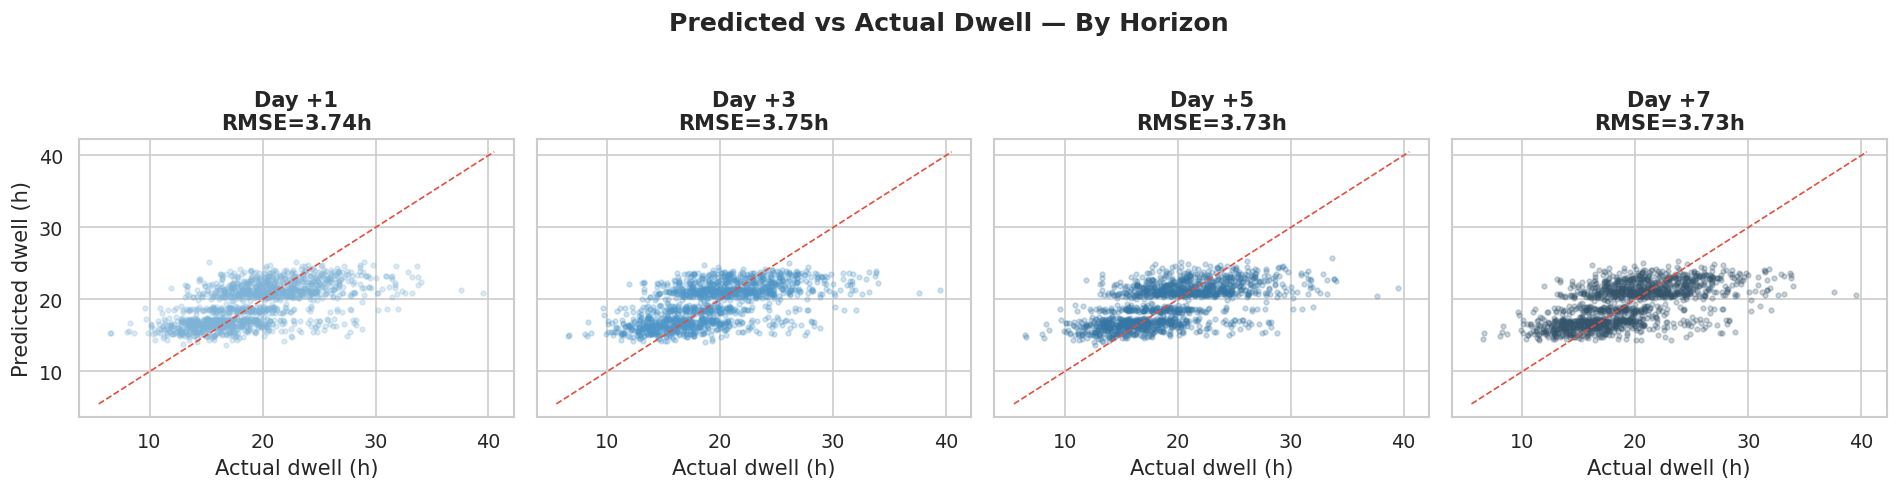

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, h in zip(axes, HORIZONS):
    r = results[h]
    ax.scatter(r["y_test"], r["y_pred"], alpha=0.25, s=8, color=sns.color_palette("Blues_d", 4)[HORIZONS.index(h)])
    lims = [
        min(r["y_test"].min(), r["y_pred"].min()) - 1,
        max(r["y_test"].max(), r["y_pred"].max()) + 1,
    ]
    ax.plot(lims, lims, "--", color="#e74c3c", linewidth=1.0)
    ax.set_title(f"Day +{h}\nRMSE={r['rmse']:.2f}h", fontweight="bold")
    ax.set_xlabel("Actual dwell (h)")
    if ax is axes[0]:
        ax.set_ylabel("Predicted dwell (h)")

fig.suptitle("Predicted vs Actual Dwell — By Horizon", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(
    Path.cwd().resolve().parent / "reports" / "figures" / "09_scatter_by_horizon.png",
    bbox_inches="tight", dpi=150
)
plt.show()

---
## 8. Threshold Usefulness — 24-Hour Dwell Breach Detection

Precise accuracy matters less than operational usefulness. The Phase 3 decision-support layer defined a **24-hour dwell breach** as the key warning threshold — situations that require immediate intervention.

For each horizon we evaluate:
- **Recall (detection rate):** Of all actual breaches, what fraction does the model flag?
- **Precision:** Of all predicted breaches, what fraction are genuine?
- **False alarm rate:** Of all non-breach days, what fraction are incorrectly flagged?

A horizon is operationally useful if it can detect most actual breaches with an acceptable false alarm rate — even if the predicted dwell value is not highly precise.

> **Consistency note:** The weak day+1 breach recall observed here is consistent with the threshold-validation results in Notebook 08, which also found that the LightGBM model underpredicts extreme dwell events due to regression-to-the-mean in tree-based models.

In [9]:
def breach_metrics(y_true: np.ndarray, y_pred: np.ndarray, threshold: float) -> dict:
    actual_breach    = y_true >= threshold
    predicted_breach = y_pred >= threshold

    n_actual    = int(actual_breach.sum())
    n_predicted = int(predicted_breach.sum())
    tp          = int((actual_breach & predicted_breach).sum())
    fp          = int((~actual_breach & predicted_breach).sum())
    fn          = int((actual_breach & ~predicted_breach).sum())
    tn          = int((~actual_breach & ~predicted_breach).sum())

    recall     = tp / n_actual if n_actual > 0 else 0.0
    precision  = tp / n_predicted if n_predicted > 0 else 0.0
    fpr        = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "Actual breaches": n_actual,
        "Predicted breaches": n_predicted,
        "True positives": tp,
        "False negatives (missed)": fn,
        "Recall (detection rate)": recall,
        "Precision": precision,
        "False alarm rate": fpr,
    }


breach_rows = []
for h in HORIZONS:
    r = results[h]
    m = breach_metrics(r["y_test"], r["y_pred"], DWELL_BREACH_THRESHOLD)
    breach_rows.append({"Horizon": f"Day +{h}", **m})

breach_df = pd.DataFrame(breach_rows).set_index("Horizon")

# Format rates as percentages for readability
for col in ["Recall (detection rate)", "Precision", "False alarm rate"]:
    breach_df[col] = breach_df[col].map(lambda x: f"{x:.1%}")

print(f"24-hour dwell breach detection — threshold ≥ {DWELL_BREACH_THRESHOLD}h")
breach_df

24-hour dwell breach detection — threshold ≥ 24.0h


,Actual breaches,Predicted breaches,True positives,False negatives (missed),Recall (detection rate),Precision,False alarm rate
Horizon,,,,,,,
Day +1,243,32,17,226,7.0%,53.1%,1.2%
Day +3,243,11,6,237,2.5%,54.5%,0.4%
Day +5,243,38,18,225,7.4%,47.4%,1.6%
Day +7,243,28,11,232,4.5%,39.3%,1.4%


### Visualising recall and precision by horizon

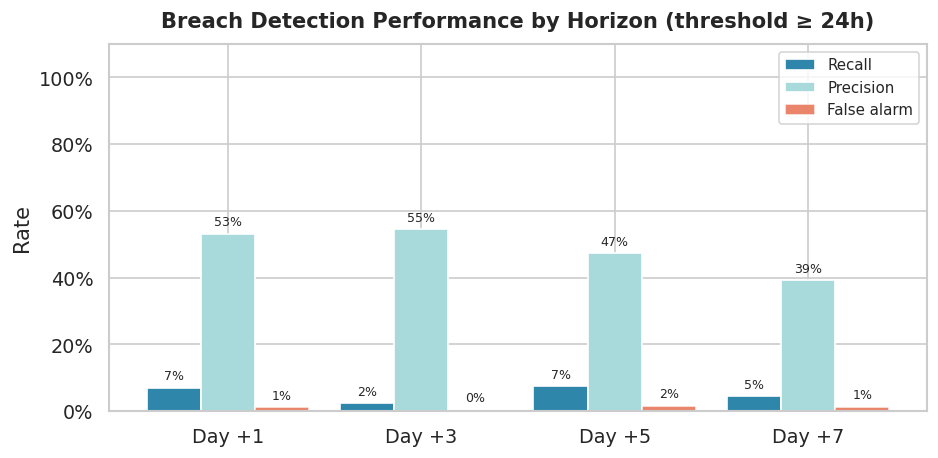

In [10]:
# Recompute numeric values for plotting
plot_rows = []
for h in HORIZONS:
    r = results[h]
    m = breach_metrics(r["y_test"], r["y_pred"], DWELL_BREACH_THRESHOLD)
    plot_rows.append({"horizon": h, **m})

plot_df = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(HORIZONS))
width = 0.28

bars_recall    = ax.bar(x - width, plot_df["Recall (detection rate)"],  width, label="Recall",      color="#2e86ab", edgecolor="white")
bars_precision = ax.bar(x,          plot_df["Precision"],                width, label="Precision",   color="#a8dadc", edgecolor="white")
bars_fpr       = ax.bar(x + width,  plot_df["False alarm rate"],         width, label="False alarm", color="#e76f51", edgecolor="white", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(horizon_labels)
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title("Breach Detection Performance by Horizon (threshold ≥ 24h)", fontweight="bold", pad=10)
ax.legend(fontsize=9)

for bar in list(bars_recall) + list(bars_precision) + list(bars_fpr):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{bar.get_height():.0%}",
        ha="center", va="bottom", fontsize=7.5
    )

plt.tight_layout()
plt.savefig(
    Path.cwd().resolve().parent / "reports" / "figures" / "09_breach_detection_by_horizon.png",
    bbox_inches="tight", dpi=150
)
plt.show()

---
## 9. Interpretation

### Accuracy across horizons — a surprising result

The results table reveals something worth pausing on: forecast accuracy does **not** materially degrade as the planning horizon extends. RMSE ranges from 3.73h to 3.75h across all four horizons — a difference of less than 0.5%. MAE follows the same pattern.

This is counter to the degradation curve typically seen in real-world operational forecasting, where noise compounds and distant futures become harder to predict. Why is it different here?

This dataset is synthetic, generated from a stable mathematical relationship between features and dwell. The same operational signals — yard occupancy, crew starts, inbound volume, locomotive availability — carry essentially equal predictive power whether we are forecasting one day or seven days ahead. The data-generating process does not introduce drift, structural breaks, or time-varying seasonality that would erode signal at longer horizons.

In a production system with real historical data, this flatness would almost certainly not hold. Genuine degradation would appear as operational conditions evolve beyond what today's snapshot can anticipate. The synthetic environment here is unusually stable, which makes the multi-step horizon comparison an architectural validation — the direct approach works cleanly — rather than a degradation study.

**What this means practically:** The direct multi-step LightGBM framework is architecturally sound. In a real deployment, the feature set would likely need to be enriched with lagged operational signals or external inputs (e.g., scheduled train arrivals, known maintenance windows) to capture horizon-specific uncertainty and produce the degradation curve that operations leaders would expect.

### Breach detection — a consistent limitation at all horizons

The breach detection results tell a different story. Recall is low across every horizon: 7.0%, 2.5%, 7.4%, and 4.5% at days +1 through +7. The model detects only a small fraction of the 243 actual 24-hour dwell breaches in the test set.

This is not a horizon problem — it is a structural one that applies equally across all four models. Tree-based regression models tend toward the mean. When extreme dwell events occur in a minority of rows, the model learns to predict nearer to the average and consistently underestimates the tail. This limitation is consistent with the Phase 1 error analysis, which also found that high-dwell events were the hardest cases to predict.

Precision is reasonable (~40–55%) — when the model does raise a breach flag, it is right more often than not. But missing more than 90% of actual breaches limits the operational value of binary threshold alerts at any horizon. Addressing this would require targeted approaches: threshold recalibration, a dedicated binary breach classifier trained on rebalanced data, or ensemble methods that give more weight to tail events.

### Summary by horizon

| Horizon | RMSE | Accuracy vs Day+1 | Breach recall | Operational use |
|---|---|---|---|---|
| Day +1 | 3.74h | Baseline | 7.0% | Tactical deployment; complement breach flag with Phase 3 risk tier |
| Day +3 | 3.75h | Flat (+0.1%) | 2.5% | Early planning trigger; use predicted dwell level, not binary breach alert |
| Day +5 | 3.73h | Flat (−0.2%) | 7.4% | Directional signal for resource review scheduling |
| Day +7 | 3.73h | Flat (−0.3%) | 4.5% | Weekly capacity trend; treat as indicative at the terminal level |

---
## 10. Phase 4 Conclusion

This notebook extended the Rail Operations Forecaster from next-day tactical forecasting into short-horizon planning support by training and evaluating direct multi-step LightGBM models at four planning horizons: day+1, day+3, day+5, and day+7.

**Key findings:**

- **The direct multi-step approach is architecturally clean.** Training a separate model for each horizon avoids recursive error compounding and produces transparent, comparable benchmarks. The Phase 1 framework scales to longer horizons without modification.

- **Accuracy is flat across all four horizons in this dataset** — RMSE stays within 3.73–3.75h regardless of horizon. This confirms that the feature set carries persistent signal, but also reflects the stability of synthetic data. In a real operational environment, forecast accuracy would be expected to degrade with horizon as conditions evolve in ways today's snapshot cannot anticipate. The framework is validated; the degradation study would require real data.

- **Breach detection is consistently weak at all horizons** — recall ranges from 2.5% to 7.4%. This is a structural limitation of regression-to-the-mean in tree models, not a horizon-specific problem. It represents the clearest gap in the current framework: high-dwell tail events are underpredicted across the board. A dedicated breach classifier or threshold recalibration would be the logical next step.

- **The per-horizon split logic matters.** Splitting on the target date (feature date + horizon) rather than the feature date ensures no leakage at the holdout boundary — an important design discipline for multi-step benchmarking.

**Phase 4 status: Complete.**

The next phase (Phase 5) would bring these multi-horizon forecasts into an interactive planning interface — combining next-day tactical signals, short-horizon trend views, scenario analysis from Phase 3, and improved breach detection into a unified operations dashboard.